# Tensile analysis of a-BN paper

This notebook combines the two plotting scripts used for the conference paper:

1. **Part 1 — Per-density stress–strain curves.** One clean stress–strain figure per
   density, with six auto-detected "characteristic frames" (early loading, pre-peak,
   near-peak, ultimate, post-peak, post-fracture) marked with Roman numerals.
2. **Part 2 — Mechanical properties vs density.** Young's modulus, yield strength
   (0.2 % offset), ultimate strength, strain at ultimate / fracture, and toughness
   extracted from each curve and plotted against density, plus a summary + LaTeX table.

Both parts read the same raw files `Strain_Stress_1.dat` … `Strain_Stress_6.dat`,
which correspond to densities 0.80, 1.00, 1.30, 1.60, 2.00, 2.30 g/cm³.

Run the cells top to bottom. Figures are shown inline **and** written to PDF/PNG in the
working directory.

## Setup — imports, plotting style, shared helpers

In [3]:
# Standard scientific stack + matplotlib.
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# In the original scripts this was matplotlib.use("Agg") (file-only, no display).
# For the notebook we keep the default backend so figures also render inline;
# every figure is still saved to disk with plt.savefig(...) as before.
%matplotlib inline

# Global publication style: serif (Times-like) fonts, STIX math, heavy axes/lines.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 20,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "axes.linewidth": 2.0,
    "lines.linewidth": 2.5,
    "lines.markersize": 10,
})


def apply_style(ax):
    """Consistent tick styling: inout major ticks, inner minor ticks, ~6 major ticks/axis."""
    ax.tick_params(axis='both', which='major', direction='inout', length=8, width=2)
    ax.tick_params(axis='both', which='minor', direction='in', length=5, width=1.5)
    ax.minorticks_on()
    ax.xaxis.set_major_locator(MaxNLocator(6))
    ax.yaxis.set_major_locator(MaxNLocator(6))


def smooth(x, w=5):
    """Simple centered moving average (window w) to suppress MD stress noise."""
    return np.convolve(x, np.ones(w) / w, mode='same')

## Data parsing

Each `.dat` line contains the box length along the tensile axis and the corresponding
stress component, in the form `... lz: <value> ... Pzz: <value> ...`. We pull those two
numbers out with a regex, then convert length to engineering strain using the first
frame as the undeformed reference length `L0`:

$$\varepsilon = \frac{l_z - L_0}{L_0}, \qquad \sigma = P_{zz}$$

In [4]:
def parse_dat(fpath):
    """Read one Strain_Stress_*.dat file -> (strain, stress) arrays.

    Extracts (lz, Pzz) from every matching line; strain is referenced to the
    first recorded length. Stress is returned raw (unsmoothed).
    """
    data = []
    with open(fpath) as f:
        for line in f:
            m = re.findall(r'lz:\s*([\d.]+).*?Pzz:\s*([-\d.e+]+)', line)
            if m:
                data.append((float(m[0][0]), float(m[0][1])))
    data = np.array(data)
    L0 = data[0, 0]                      # undeformed reference length
    strain = (data[:, 0] - L0) / L0
    stress = data[:, 1]
    return strain, stress


# Density (g/cm^3) associated with each file index 1..6 — used by both parts.
densities = {1: 0.80, 2: 1.00, 3: 1.30, 4: 1.60, 5: 2.00, 6: 2.30}

# Part 1 — Per-density stress–strain curves

For every density we draw the raw curve (faint) and the smoothed curve (bold), then mark
six **characteristic frames** so the accompanying MD snapshots can be cross-referenced:

| Frame | Roughly where |
|-------|---------------|
| I     | very early loading (`idx_ult // 10`) |
| II    | ~⅓ of the way to the peak |
| III   | ~⅔ of the way to the peak |
| IV    | ultimate stress (peak) |
| V     | halfway between peak and fracture |
| VI    | just past fracture (peak has dropped below 50 %) |

`auto_detect` clamps every index into range and guarantees six distinct frames.

In [5]:
def auto_detect(strain, stress_s):
    """Pick six representative frame indices along a smoothed stress-strain curve.

    Fracture is defined as the first post-peak point where the smoothed stress
    falls below 50 % of the ultimate value.
    """
    ntot = len(strain)
    idx_ult = np.argmax(stress_s)                       # peak (ultimate) stress

    post = np.arange(idx_ult, ntot)
    b50 = post[stress_s[post] < 0.5 * stress_s[idx_ult]]
    idx_frac = b50[0] if len(b50) else ntot - 1         # fracture index

    frames = sorted(set([
        min(max(5, idx_ult // 10), ntot - 1),          # I   early loading
        min(max(10, idx_ult // 3), ntot - 1),          # II  ~1/3 to peak
        min(max(15, 2 * idx_ult // 3), ntot - 1),      # III ~2/3 to peak
        min(idx_ult, ntot - 1),                        # IV  ultimate
        min((idx_ult + idx_frac) // 2, ntot - 1),      # V   peak..fracture midpoint
        min(idx_frac + 30, ntot - 1),                  # VI  just past fracture
    ]))
    while len(frames) < 6:                              # pad if any collapsed together
        frames.append(min(frames[-1] + 20, ntot - 1))
    return sorted(set(frames))[:6]

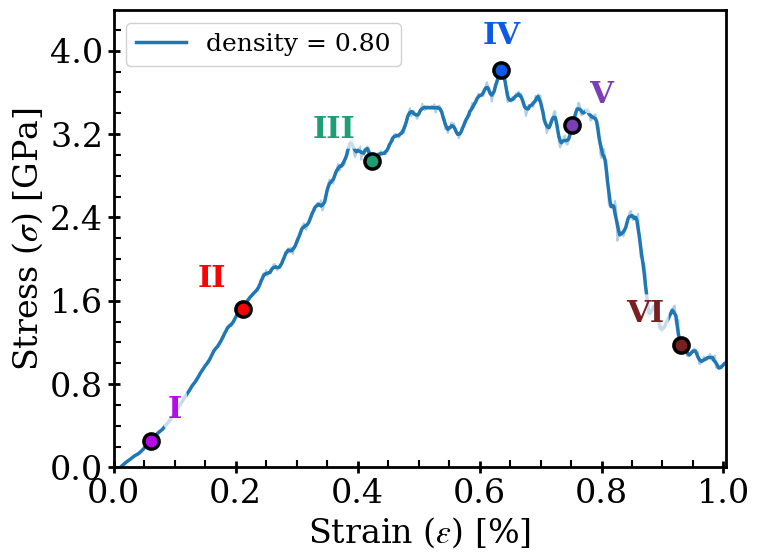

rho=0.8: frames=[np.int64(31), np.int64(106), np.int64(212), np.int64(318), np.int64(376), np.int64(465)], strains=[0.062, 0.212, 0.424, 0.636, 0.752, 0.930] -> ss_080.pdf


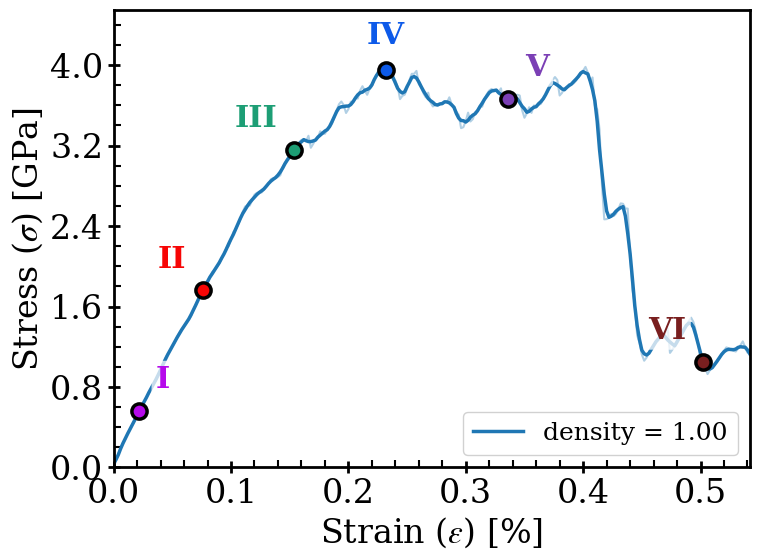

rho=1.0: frames=[np.int64(11), np.int64(38), np.int64(77), np.int64(116), np.int64(168), np.int64(251)], strains=[0.022, 0.076, 0.154, 0.232, 0.336, 0.502] -> ss_100.pdf


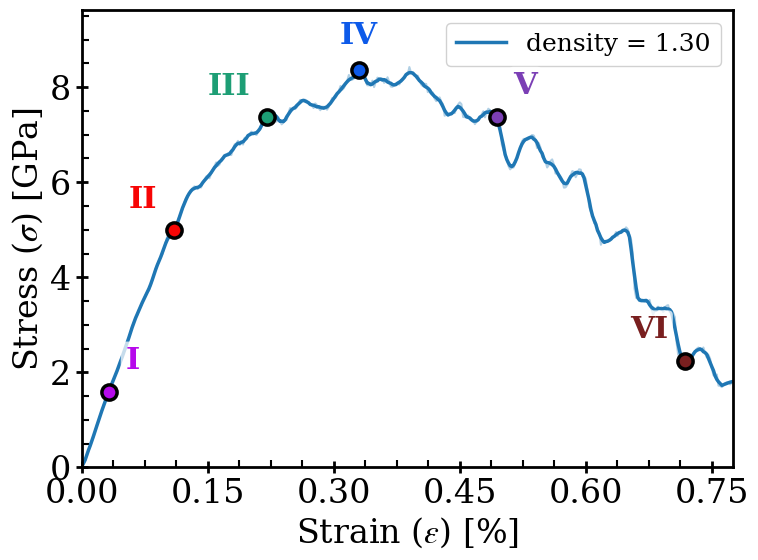

rho=1.3: frames=[np.int64(16), np.int64(55), np.int64(110), np.int64(165), np.int64(247), np.int64(359)], strains=[0.032, 0.110, 0.220, 0.330, 0.494, 0.718] -> ss_130.pdf


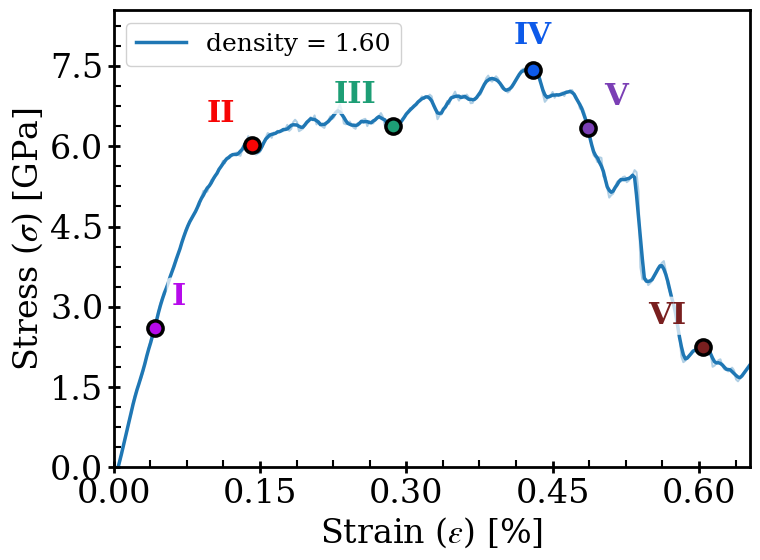

rho=1.6: frames=[np.int64(21), np.int64(71), np.int64(143), np.int64(215), np.int64(243), np.int64(302)], strains=[0.042, 0.142, 0.286, 0.430, 0.486, 0.604] -> ss_160.pdf


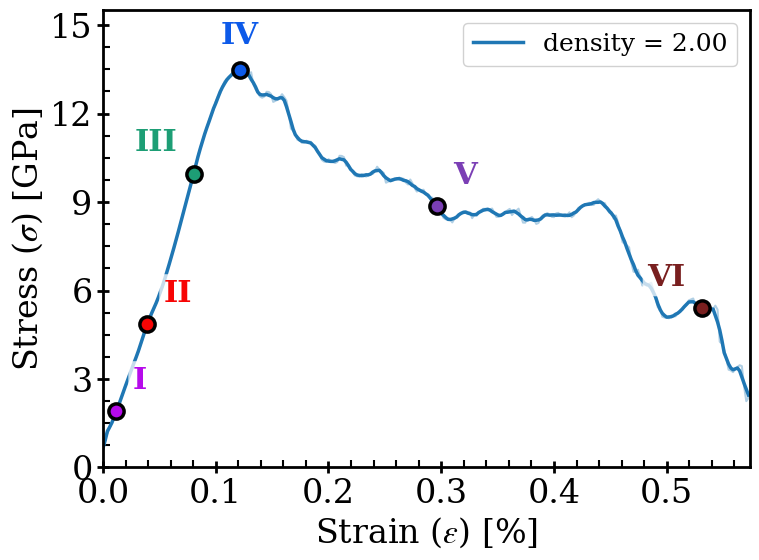

rho=2.0: frames=[np.int64(6), np.int64(20), np.int64(41), np.int64(62), np.int64(151), np.int64(271)], strains=[0.012, 0.039, 0.080, 0.122, 0.296, 0.531] -> ss_200.pdf


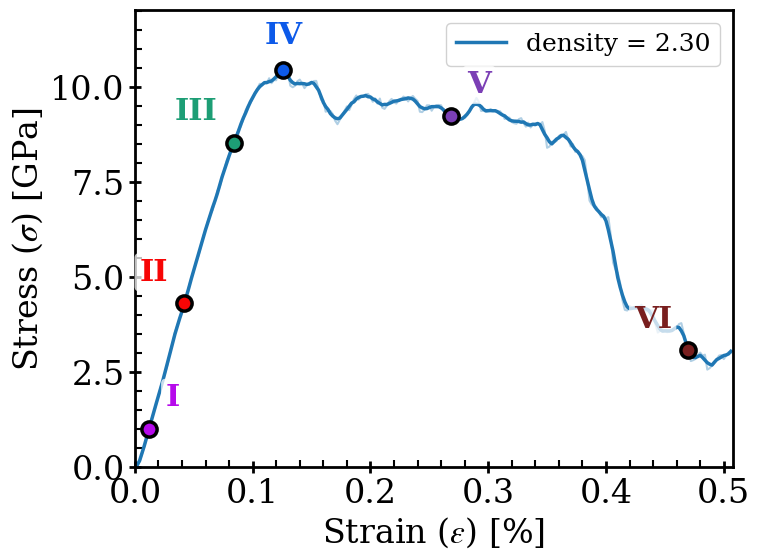

rho=2.3: frames=[np.int64(6), np.int64(21), np.int64(42), np.int64(63), np.int64(134), np.int64(235)], strains=[0.012, 0.042, 0.084, 0.126, 0.268, 0.470] -> ss_230.pdf

Part 1 done — all 6 stress-strain figures saved.


In [51]:
# Cosmetic labels for the six figures / six frames.
panels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
roman  = ['I', 'II', 'III', 'IV', 'V', 'VI']

colors = ["#B60AEB", "#F70505", '#1D9E75', "#0D5AE9", '#7B3FB5', '#791F1F']

for (i, rho), panel in zip(densities.items(), panels):

    strain, stress = parse_dat(f'Strain_Stress_{i}.dat')
    stress_s = smooth(stress)
    frames = auto_detect(strain, stress_s)

    # x-limit: a little past the last marked frame, but at least 0.5 strain
    # (and never beyond the available data).
    xmax_data = strain[frames[-1]] * 1.08
    xmax = min(max(xmax_data, 0.5), strain[-1])
    mask = strain <= xmax
    ymax = stress_s[mask].max()
    idx_ult = np.argmax(stress_s)          # peak index — splits loading vs post-peak branch

    fig, ax = plt.subplots(figsize=(8, 6))

    # Raw curve (faint) under the smoothed curve (bold).
    ax.plot(strain[mask], stress[mask], '-', color='#1f77b4', lw=1.5, alpha=0.35)
    ax.plot(strain[mask], stress_s[mask], '-', color='#1f77b4', lw=2.5,
            label=f'density = {rho:.2f}')

    # Mark the six characteristic frames with coloured dots + Roman numerals.
    # The numeral is pushed AWAY from the curve with a fixed point offset so it
    # never lands on the line: up-left on the rising branch, up-right after the
    # peak, straight up at the peak itself. A faint white box keeps it legible.
    for k, f in enumerate(frames):
        if f >= len(strain) or strain[f] > xmax:
            continue
        sx, sy = strain[f], stress_s[f]
        ax.scatter([sx], [sy], color=colors[k], s=120, zorder=5,
                   edgecolor='k', linewidth=2.5)
        frac = sx / xmax
        if frac < 0.08:                    # hugging the left axis -> push right instead
            dx, dy, ha = 12, 12, 'left'
        elif frac > 0.90:                  # hugging the right axis -> push left instead
            dx, dy, ha = -12, 12, 'right'
        elif f < idx_ult:                  # loading branch: curve is down-right of the label
            dx, dy, ha = -12, 12, 'right'
        elif f > idx_ult:                  # post-peak branch: curve is down-left of the label
            dx, dy, ha = 12, 12, 'left'
        else:                             # at the peak
            dx, dy, ha = 0, 14, 'center'
        ax.annotate(roman[k], (sx, sy), textcoords='offset points', xytext=(dx, dy),
                    ha=ha, va='bottom', fontsize=22, fontweight='bold', color=colors[k],
                    zorder=6,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75))

    ax.set_xlabel('Strain ($\\varepsilon$) [%]', fontsize=24)
    ax.set_ylabel('Stress ($\\sigma$) [GPa]', fontsize=24)
    ax.legend(loc='best', framealpha=0.9)
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax * 1.15)            # headroom so numerals above the peak aren't clipped
    apply_style(ax)
    plt.tight_layout()

    # e.g. rho = 0.80 -> ss_080.pdf
    rho_str = f'{rho:.2f}'.replace('.', '')
    plt.savefig(f'ss_{rho_str}.pdf', format='pdf', bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"rho={rho}: frames={frames}, "
          f"strains=[{', '.join(f'{strain[f]:.3f}' for f in frames)}] -> ss_{rho_str}.pdf")

print("\nPart 1 done — all 6 stress-strain figures saved.")

# Part 2 — Mechanical properties vs density

`parse_and_analyze` turns one curve into a dictionary of scalar properties:

* **Young's modulus `E`** — linear fit of stress vs strain over an adaptive window:
  from `ε > 0.005` up to whichever comes first of "30 % of ultimate stress" or `ε = 0.15`
  (falls back to `ε ∈ (0.005, 0.05)` if too few points).
* **Yield (0.2 % offset)** — first crossing of the offset line `E·(ε − 0.002) + b` with the
  smoothed curve, required to sit after `ε = 0.02`, before the ultimate point, and above
  20 % of ultimate stress. If no clean crossing, fall back to the first point deviating
  > 5 % from the elastic line.
* **Ultimate** — peak of the smoothed stress and its strain.
* **Fracture strain** — first post-peak point below 50 % of ultimate stress.
* **Toughness** — `∫ σ dε` (trapezoid) from zero strain up to fracture, in GJ/m³.

In [7]:
def parse_and_analyze(fpath, rho):
    """Extract E, yield, ultimate, fracture strain and toughness from one .dat file."""
    strain, stress = parse_dat(fpath)
    stress_s = smooth(stress)

    # --- Young's modulus: adaptive linear fit of the elastic region ------------
    idx_ult = np.argmax(stress_s)
    sig30 = 0.3 * stress_s[idx_ult]
    lin_end = strain[np.argmax(stress_s > sig30)]          # strain where curve hits 30% ult
    lin = (strain > 0.005) & (strain < min(lin_end, 0.15))
    if lin.sum() < 5:                                       # too few points -> wider fallback
        lin = (strain > 0.005) & (strain < 0.05)
    E, b = np.polyfit(strain[lin], stress[lin], 1)

    # --- Yield point: 0.2% offset method, constrained to be before ultimate ----
    offset = E * (strain - 0.002) + b
    diff = stress_s - offset
    sc = np.where(np.diff(np.sign(diff)) != 0)[0]           # sign changes = crossings
    valid = sc[(strain[sc] > 0.02) & (sc < idx_ult) &
               (stress_s[sc] > 0.2 * stress_s[idx_ult])]
    if len(valid) > 0:
        idx_yield = valid[0]
    else:
        # Fallback: first point deviating >5% from the pure elastic line.
        with np.errstate(divide='ignore', invalid='ignore'):
            dev = np.abs(stress_s - (E * strain + b)) / np.abs(E * strain + b + 1e-9)
        cand = np.where((strain > 0.02) & (dev > 0.05) &
                        (np.arange(len(strain)) < idx_ult) &
                        (stress_s > 0.2 * stress_s[idx_ult]))[0]
        idx_yield = cand[0] if len(cand) else idx_ult // 2

    # --- Toughness: area under the curve up to fracture -----------------------
    post = np.arange(idx_ult, len(stress_s))
    b50 = post[stress_s[post] < 0.5 * stress_s[idx_ult]]
    idx_frac = b50[0] if len(b50) else len(stress_s) - 1
    toughness = np.trapz(stress_s[:idx_frac], strain[:idx_frac])

    return {
        'rho': rho,
        'E': E,
        'yield_stress': stress[idx_yield],
        'yield_strain': strain[idx_yield],
        'ult_stress': stress[idx_ult],
        'ult_strain': strain[idx_ult],
        'frac_strain': strain[idx_frac],
        'toughness': toughness,
    }

In [8]:
# Run the analysis for all six densities.
results = []
for i, rho in densities.items():
    r = parse_and_analyze(f'Strain_Stress_{i}.dat', rho)
    results.append(r)
    print(f"rho={rho}: E={r['E']:.1f}, sig_y={r['yield_stress']:.2f}, "
          f"sig_ult={r['ult_stress']:.2f}, eps_ult={r['ult_strain']:.3f}, "
          f"T={r['toughness']:.2f}")

# Unpack into per-property lists for plotting.
rhos     = [r['rho'] for r in results]
Es       = [r['E'] for r in results]
sig_y    = [r['yield_stress'] for r in results]
sig_ult  = [r['ult_stress'] for r in results]
eps_ult  = [r['ult_strain'] for r in results]
eps_frac = [r['frac_strain'] for r in results]
tough    = [r['toughness'] for r in results]

rho=0.8: E=6.9, sig_y=3.46, sig_ult=3.83, eps_ult=0.636, T=2.07
rho=1.0: E=22.9, sig_y=1.43, sig_ult=3.95, eps_ult=0.232, T=1.28
rho=1.3: E=49.1, sig_y=3.55, sig_ult=8.44, eps_ult=0.330, T=4.08
rho=1.6: E=70.0, sig_y=3.23, sig_ult=7.43, eps_ult=0.430, T=3.14
rho=2.0: E=103.5, sig_y=7.97, sig_ult=13.47, eps_ult=0.122, T=4.28
rho=2.3: E=110.4, sig_y=7.61, sig_ult=10.56, eps_ult=0.126, T=3.34


/tmp/ipykernel_41170/205997077.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  toughness = np.trapz(stress_s[:idx_frac], strain[:idx_frac])


In [9]:
# The property-vs-density figures use larger tick labels than Part 1.
plt.rcParams.update({"xtick.labelsize": 24, "ytick.labelsize": 24})

### Figure 1 — Young's modulus vs density

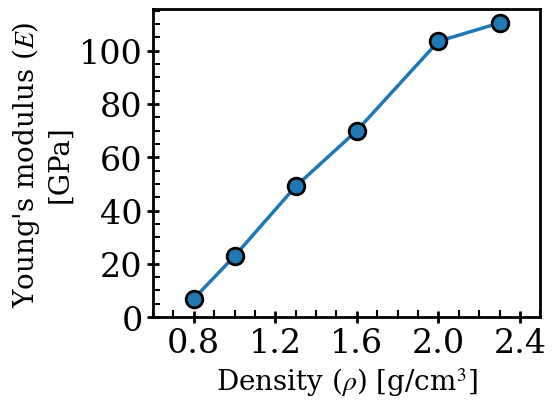

Saved E_vs_density


In [23]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rhos, Es, 'o-', color='#1f77b4', markersize=12, markeredgecolor='k',
        markeredgewidth=2.0)
ax.set_xlabel('Density ($\\rho$) [g/cm$^3$]', fontsize=20)
ax.set_ylabel("Young's modulus ($E$) \n[GPa]", fontsize=20)
ax.set_xlim(0.6, 2.5)
ax.set_ylim(bottom=0)
apply_style(ax)
plt.savefig('E_vs_density.pdf', format='pdf', bbox_inches='tight', facecolor='white')
plt.savefig('E_vs_density.png', format='png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved E_vs_density")

### Figure 2 — Strength vs density (yield + ultimate)

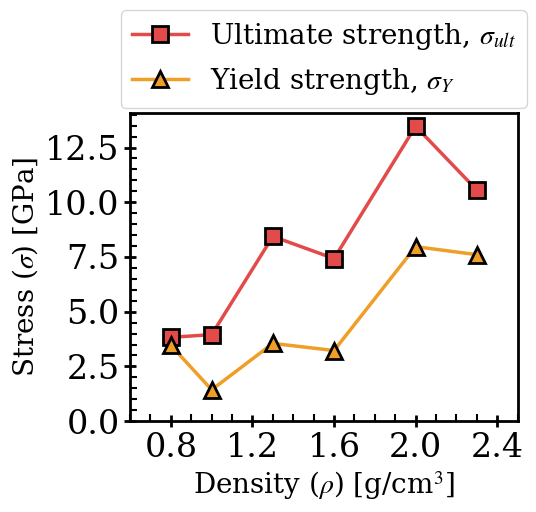

Saved strength_vs_density


In [36]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rhos, sig_ult, 's-', color='#E24B4A', markersize=12, markeredgecolor='k',
        markeredgewidth=2.0, label='Ultimate strength, $\\sigma_{ult}$')
ax.plot(rhos, sig_y, '^-', color='#EF9F27', markersize=12, markeredgecolor='k',
        markeredgewidth=2.0, label='Yield strength, $\\sigma_{Y}$')
ax.set_xlabel('Density ($\\rho$) [g/cm$^3$]', fontsize=20)
ax.set_ylabel('Stress ($\\sigma$) [GPa]', fontsize=20)
ax.set_xlim(0.6, 2.5)
ax.set_ylim(bottom=0)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.38), ncol=1,
          frameon=True, fontsize=20)
apply_style(ax)
plt.savefig('strength_vs_density.pdf', format='pdf', bbox_inches='tight', facecolor='white')
plt.savefig('strength_vs_density.png', format='png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved strength_vs_density")

### Figure 3 — Ductility vs density (strain at ultimate + fracture)

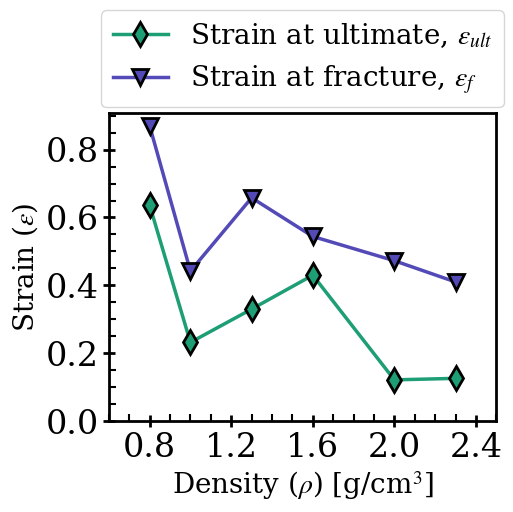

Saved ductility_vs_density


In [37]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rhos, eps_ult, 'd-', color='#1D9E75', markersize=12, markeredgecolor='k',
        markeredgewidth=2.0, label='Strain at ultimate, $\\varepsilon_{ult}$')
ax.plot(rhos, eps_frac, 'v-', color='#534AB7', markersize=12, markeredgecolor='k',
        markeredgewidth=2.0, label='Strain at fracture, $\\varepsilon_{f}$')
ax.set_xlabel('Density ($\\rho$) [g/cm$^3$]', fontsize=20)
ax.set_ylabel('Strain ($\\varepsilon$)', fontsize=20)
ax.set_xlim(0.6, 2.5)
ax.set_ylim(bottom=0)
apply_style(ax)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.38), ncol=1,
          frameon=True, fontsize=20)
plt.savefig('ductility_vs_density.pdf', format='pdf', bbox_inches='tight', facecolor='white')
plt.savefig('ductility_vs_density.png', format='png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved ductility_vs_density")

### Figure 4 — Toughness vs density

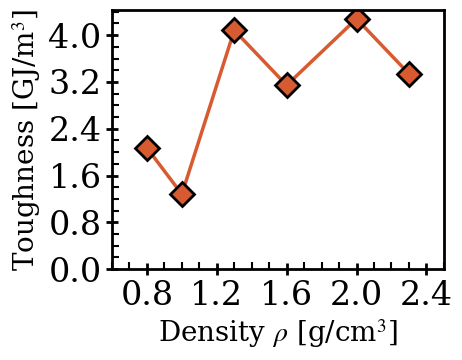

Saved toughness_vs_density


In [31]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rhos, tough, 'D-', color='#D85A30', markersize=12, markeredgecolor='k',
        markeredgewidth=2.0)
ax.set_xlabel('Density $\\rho$ [g/cm$^3$]', fontsize=20)
ax.set_ylabel('Toughness [GJ/m$^3$]', fontsize=20)
ax.set_xlim(0.6, 2.5)
ax.set_ylim(bottom=0)
apply_style(ax)
plt.tight_layout()
plt.savefig('toughness_vs_density.pdf', format='pdf', bbox_inches='tight', facecolor='white')
plt.savefig('toughness_vs_density.png', format='png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved toughness_vs_density")

### Summary table (plain text)

In [12]:
print("=" * 80)
print("SUMMARY TABLE FOR PAPER")
print("=" * 80)
print(f"{'rho':>6} {'E':>8} {'sig_y':>8} {'sig_ult':>8} {'eps_ult':>8} {'eps_f':>8} {'T':>8}")
print(f"{'g/cm3':>6} {'GPa':>8} {'GPa':>8} {'GPa':>8} {'':>8} {'':>8} {'GJ/m3':>8}")
print("-" * 80)
for r in results:
    print(f"{r['rho']:>6.2f} {r['E']:>8.1f} {r['yield_stress']:>8.2f} "
          f"{r['ult_stress']:>8.2f} {r['ult_strain']:>8.3f} "
          f"{r['frac_strain']:>8.3f} {r['toughness']:>8.2f}")

SUMMARY TABLE FOR PAPER
   rho        E    sig_y  sig_ult  eps_ult    eps_f        T
 g/cm3      GPa      GPa      GPa                      GJ/m3
--------------------------------------------------------------------------------
  0.80      6.9     3.46     3.83    0.636    0.870     2.07
  1.00     22.9     1.43     3.95    0.232    0.442     1.28
  1.30     49.1     3.55     8.44    0.330    0.658     4.08
  1.60     70.0     3.23     7.43    0.430    0.544     3.14
  2.00    103.5     7.97    13.47    0.122    0.473     4.28
  2.30    110.4     7.61    10.56    0.126    0.410     3.34


### Summary table (LaTeX, ready to paste into the paper)

In [13]:
print(r"\begin{table}[h!]")
print(r"\centering")
print(r"\caption{Mechanical properties of a-BN at varying densities.}")
print(r"\label{tab:mech_props}")
print(r"\begin{tabular}{ccccccc}")
print(r"\hline")
print(r"$\rho$ & $E$ & $\sigma_y$ & $\sigma_{ult}$ & $\varepsilon_{ult}$ & $\varepsilon_f$ & Toughness \\")
print(r"(g/cm$^3$) & (GPa) & (GPa) & (GPa) & & & (GJ/m$^3$) \\")
print(r"\hline")
for r in results:
    print(f"{r['rho']:.2f} & {r['E']:.1f} & {r['yield_stress']:.2f} & "
          f"{r['ult_stress']:.2f} & {r['ult_strain']:.3f} & "
          f"{r['frac_strain']:.3f} & {r['toughness']:.2f} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

print("\nAll done!")

\begin{table}[h!]
\centering
\caption{Mechanical properties of a-BN at varying densities.}
\label{tab:mech_props}
\begin{tabular}{ccccccc}
\hline
$\rho$ & $E$ & $\sigma_y$ & $\sigma_{ult}$ & $\varepsilon_{ult}$ & $\varepsilon_f$ & Toughness \\
(g/cm$^3$) & (GPa) & (GPa) & (GPa) & & & (GJ/m$^3$) \\
\hline
0.80 & 6.9 & 3.46 & 3.83 & 0.636 & 0.870 & 2.07 \\
1.00 & 22.9 & 1.43 & 3.95 & 0.232 & 0.442 & 1.28 \\
1.30 & 49.1 & 3.55 & 8.44 & 0.330 & 0.658 & 4.08 \\
1.60 & 70.0 & 3.23 & 7.43 & 0.430 & 0.544 & 3.14 \\
2.00 & 103.5 & 7.97 & 13.47 & 0.122 & 0.473 & 4.28 \\
2.30 & 110.4 & 7.61 & 10.56 & 0.126 & 0.410 & 3.34 \\
\hline
\end{tabular}
\end{table}

All done!
